**Українська версія:**

Дослідницький Аналіз Даних (EDA)

У цьому ноутбуці проводиться дослідницький аналіз даних клієнтів телекомунікаційної компанії з метою розуміння основних закономірностей та характеристик набору даних перед побудовою моделі прогнозування відтоку.

Завдання:

1. Вивчення розподілів ключових ознак (демографічні дані, тривалість користування послугами, тарифи, тип контракту тощо)
2. Виявлення відсутніх значень та оцінка їхнього впливу на набір даних
3. Аналіз кореляцій між ознаками та цільовою змінною (Churn)
4. Виявлення потенційних викидів та проблем якості даних, які потребуватимуть уваги на етапі попередньої обробки

Висновки, отримані на цьому етапі, безпосередньо визначатимуть кроки попередньої обробки даних на наступному етапі проєкту.

**English version:**

Exploratory Data Analysis (EDA)

This notebook performs exploratory data analysis on the telecom customer dataset to understand the underlying patterns and characteristics before building a churn prediction model.

Goals:

1. Explore the distribution of key features (demographics, tenure, charges, contract types, etc.)
2. Identify missing values and assess their impact on the dataset
3. Analyze correlations between features and the target variable (Churn)
4. Detect potential outliers and data quality issues that may require attention during preprocessing

The insights gathered here will directly inform the preprocessing steps in the next stage of the project.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

#### Розділ функцій (Functions section) 

In [2]:
    
def get_churn_distribution(min_value, max_value,column_comparison, interval,procedural_slip) -> dict:
    """ 
    Українська версія: Функція обчислює кількість випадків відтоку для кожного кроку в заданій колонці набору даних 
    і повертає словник, що містить набір записів по кроках, кожен з яких містить інтервал колонки та відповідну кількість відтоку.

    English version: The function calculates the quantity of churns per step in a given dataset column, 
    and returns a dictionary containing a set of step-level entries, each with the column interval and 
    the corresponding churn quantity.
    """
    dict_values = {}

    previous_ind = 0
    attempt = 0
    i = min_value
    
    while (i <= max_value + procedural_slip):
    
        if attempt == 0:
            column_value = i
            churn_quantity = df_copy.loc[df_copy[column_comparison] <= i, 'churn'].sum()
            attempt = 1
        else:
            column_value = i
            churn_quantity = df_copy.loc[(df_copy[column_comparison] > previous_ind) & (df_copy[column_comparison] <= i), 'churn'].sum()
            
        list_values = {}
        final_result = {f'{column_comparison}': column_value, 'churn_quantity': churn_quantity}
        dict_values[f'{i}_step:'] = final_result
        previous_ind = i
        i += interval
        
    return dict_values

In [3]:
    

def return_results_as_lists(min_value, max_value, column_comparison, dictionary,interval,procedural_slip):
    """ 
    Українська версія: Функція повертає два списки для спрощення подальших обчислень або графічного представлення 
    залежності між інтервалами колонки та кількістю відтоку.
    
    English version: The function returns two lists for simpler further calculations or graphical representation 
    of the relationship between column intervals and churn quantity.
    """ 
    i = min_value
    list_column_values = []
    list_churn_quantity = []
    
    while (i <= max_value + procedural_slip):
        list_column_values.append(dictionary[f'{i}_step:'][column_comparison])
        list_churn_quantity.append(dictionary[f'{i}_step:']['churn_quantity'])
        i += interval
        
    return list_column_values,list_churn_quantity

In [48]:

def show_all_churn_piecharts(request_column: str, labels: list, all_title: str, churns_title: str) -> None:
    """
    Ukrainian version:
    Будує два кругові графіки для заданої колонки (`request_column`):
      1. Частка клієнтів із ненульовим значенням колонки серед УСІХ клієнтів.
      2. Частка клієнтів із ненульовим значенням колонки серед КЛІЄНТІВ, ЩО ПІШЛИ (churn=1).
    
    English version: 
    Builds two pie charts for the given column (`request_column`):
      1. Share of customers with a non-zero value in the column, among ALL customers.
      2. Share of customers with a non-zero value in the column, among CHURNED customers only.
    """
    
    churns_without_failures = df_copy[df_copy[request_column] == 0]['churn'].sum()
    churns_with_failures = df_copy[df_copy[request_column] > 0]['churn'].sum()

    all_failures = df_copy.loc[df_copy[request_column] > 0][request_column].sum()
    no_failures = df_copy[request_column].shape[0] - all_failures

    fig, axs = plt.subplots(1, 2, figsize=(12,12))

    data_all = [all_failures, no_failures]

    axs[0].set_title(all_title)
    axs[0].pie(data_all,labels=labels,autopct="%.2f%%",colors=['Teal','Salmon'],shadow=False, labeldistance=1.1, startangle=0, radius=1)

    data_churns = [churns_with_failures, churns_without_failures]
    axs[1].set_title(churns_title)
    axs[1].pie(data_churns,labels=labels,autopct="%.2f%%",colors=['green','orange'],shadow=False, labeldistance=1.1, startangle=0, radius=1)
    plt.tight_layout()
    plt.show()

In [5]:
df = pd.read_csv('../data/raw/internet_service_churn.csv')

In [6]:
df.head(10)

,id,is_tv_subscriber,is_movie_package_subscriber,subscription_age,bill_avg,reamining_contract,service_failure_count,download_avg,upload_avg,download_over_limit,churn
0,15,1,0,11.95,25,0.14,0,8.4,2.3,0,0
1,18,0,0,8.22,0,NaN,0,0.0,0.0,0,1
2,23,1,0,8.91,16,0.00,0,13.7,0.9,0,1
3,27,0,0,6.87,21,NaN,1,0.0,0.0,0,1
4,34,0,0,6.39,0,NaN,0,0.0,0.0,0,1
5,56,1,1,11.94,32,1.38,0,69.4,4.0,0,0
6,71,0,0,8.96,18,0.00,0,21.3,2.0,0,1
7,84,0,0,5.48,14,NaN,1,0.0,0.0,0,1
8,94,0,0,8.54,0,NaN,0,0.0,0.0,0,1
9,112,0,0,8.33,0,NaN,0,0.0,0.0,0,1


**Українська версія:**    
Помилку в назві стовпця, а саме «reamining_contract», необхідно виправити, надавши їй правильне значення — «remaining contract»

**English version:**   
The error in the column name, specifically “reamining_contract,” must be corrected by replacing it with the correct value —“remaining contract.”

In [7]:
df = df.rename(columns={'reamining_contract': 'remaining_contract'})

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72274 entries, 0 to 72273
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           72274 non-null  int64  
 1   is_tv_subscriber             72274 non-null  int64  
 2   is_movie_package_subscriber  72274 non-null  int64  
 3   subscription_age             72274 non-null  float64
 4   bill_avg                     72274 non-null  int64  
 5   remaining_contract           50702 non-null  float64
 6   service_failure_count        72274 non-null  int64  
 7   download_avg                 71893 non-null  float64
 8   upload_avg                   71893 non-null  float64
 9   download_over_limit          72274 non-null  int64  
 10  churn                        72274 non-null  int64  
dtypes: float64(4), int64(7)
memory usage: 6.1 MB


In [9]:
df.describe()

,id,is_tv_subscriber,is_movie_package_subscriber,subscription_age,bill_avg,remaining_contract,service_failure_count,download_avg,upload_avg,download_over_limit,churn
count,7.227400e+04,72274.000000,72274.000000,72274.000000,72274.000000,50702.000000,72274.000000,71893.000000,71893.000000,72274.000000,72274.000000
mean,8.463182e+05,0.815259,0.334629,2.450051,18.942483,0.716039,0.274234,43.689911,4.192076,0.207613,0.554141
std,4.891022e+05,0.388090,0.471864,2.034990,13.215386,0.697102,0.816621,63.405963,9.818896,0.997123,0.497064
min,1.500000e+01,0.000000,0.000000,-0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.222165e+05,1.000000,0.000000,0.930000,13.000000,0.000000,0.000000,6.700000,0.500000,0.000000,0.000000
50%,8.477840e+05,1.000000,0.000000,1.980000,19.000000,0.570000,0.000000,27.800000,2.100000,0.000000,1.000000
75%,1.269562e+06,1.000000,1.000000,3.300000,22.000000,1.310000,0.000000,60.500000,4.800000,0.000000,1.000000
max,1.689744e+06,1.000000,1.000000,12.800000,406.000000,2.920000,19.000000,4415.200000,453.300000,7.000000,1.000000


In [10]:
df[df['subscription_age'] < 0]

,id,is_tv_subscriber,is_movie_package_subscriber,subscription_age,bill_avg,remaining_contract,service_failure_count,download_avg,upload_avg,download_over_limit,churn
69320,1621523,0,0,-0.02,0,0.08,0,32.6,1.3,0,1


In [11]:
df.loc[df['subscription_age'] < 0, 'subscription_age'] = 0

In [12]:
duplications_amount = df.duplicated().sum()
if duplications_amount > 0:
    df = df.drop_duplicates()
    df
duplications_amount

0

In [13]:
churn_percentage = round(df['churn'].mean() * 100,2)
print(f'рівень відтоку клієнтів становить {churn_percentage}% з набору даних')
# print(f'The customer churn rate is {churn_percentage} from dataset')

рівень відтоку клієнтів становить 55.41% з набору даних


In [14]:
df.head(15)

,id,is_tv_subscriber,is_movie_package_subscriber,subscription_age,bill_avg,remaining_contract,service_failure_count,download_avg,upload_avg,download_over_limit,churn
0,15,1,0,11.95,25,0.14,0,8.4,2.3,0,0
1,18,0,0,8.22,0,NaN,0,0.0,0.0,0,1
2,23,1,0,8.91,16,0.00,0,13.7,0.9,0,1
3,27,0,0,6.87,21,NaN,1,0.0,0.0,0,1
4,34,0,0,6.39,0,NaN,0,0.0,0.0,0,1
5,56,1,1,11.94,32,1.38,0,69.4,4.0,0,0
6,71,0,0,8.96,18,0.00,0,21.3,2.0,0,1
7,84,0,0,5.48,14,NaN,1,0.0,0.0,0,1
8,94,0,0,8.54,0,NaN,0,0.0,0.0,0,1
9,112,0,0,8.33,0,NaN,0,0.0,0.0,0,1


In [15]:
df['is_tv_subscriber'].value_counts()

is_tv_subscriber
1    58922
0    13352
Name: count, dtype: int64

In [16]:
df['is_movie_package_subscriber'].value_counts()

is_movie_package_subscriber
0    48089
1    24185
Name: count, dtype: int64

**Українська версія:**  
Оскільки в наборі даних представлені лише окремі значення щодо наявності підписок на телевізійні та кінопакети, варто з’ясувати кількість користувачів, які мають обидві підписки, оскільки це може вплинути на потенційний відтік клієнтів.

**English Version:**    
Since the dataset contains only individual values regarding subscriptions to TV and movie packages, it is worth determining the number of users who have both subscriptions, as this could affect potential customer churn.

In [17]:
dual_subscription = ((df['is_tv_subscriber'] == 1) & (df['is_movie_package_subscriber'] == 1)).sum()
print('Користувачі, які мають подвійну підписку: ', dual_subscription)
# print('Users that have a dual subscription: ', dual_subscription)

Користувачі, які мають подвійну підписку:  24183


In [18]:
percentage_of_dual_subscription = round((dual_subscription / df.shape[0]) * 100,2)
print(f'{percentage_of_dual_subscription}% користувачів мають підписку як на телевізійний, так і на кінопакет.')
# print(f'{percentage_of_dual_subscription}% of users have both tv and movie-package subscriptions')

33.46% користувачів мають підписку як на телевізійний, так і на кінопакет.


**Українська версія:**  
З огляду на те, що більше третини користувачів мають передплату як на телебачення, так і на кінопакет, що не відображено належним чином у наборі даних, для урахування цього фактора необхідно створити стовпець «подвійна передплата».

**English Version:**    
Considering the fact that more than third users have both tv and movie-package subscription that is not properly stated in the dataset, in order to keep its impact the column of dual subscription must be created.

In [19]:
df['dual_subscriber'] = ((df['is_tv_subscriber'] == 1) & (df['is_movie_package_subscriber'] == 1)).astype('int')
df.head(-5)

,id,is_tv_subscriber,is_movie_package_subscriber,subscription_age,bill_avg,remaining_contract,service_failure_count,download_avg,upload_avg,download_over_limit,churn,dual_subscriber
0,15,1,0,11.95,25,0.14,0,8.4,2.3,0,0,0
1,18,0,0,8.22,0,NaN,0,0.0,0.0,0,1,0
2,23,1,0,8.91,16,0.00,0,13.7,0.9,0,1,0
3,27,0,0,6.87,21,NaN,1,0.0,0.0,0,1,0
4,34,0,0,6.39,0,NaN,0,0.0,0.0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
72264,1689533,0,0,0.01,0,NaN,0,0.0,0.0,0,1,0
72265,1689546,1,0,0.00,1,0.32,0,0.0,0.0,0,1,0
72266,1689554,1,1,0.04,7,1.93,1,5.8,0.9,0,1,1
72267,1689600,0,0,0.08,0,NaN,0,84.2,5.0,0,1,0


**Українська версія:**   
Наступним кроком буде пошук відповідного рішення для заповнення значень NaN.

**English version:**   
Next step would be to find the proper solution for filling NaN values.

In [20]:
df.groupby(df['remaining_contract'].isna())['churn'].mean()

remaining_contract
False    0.400990
True     0.914102
Name: churn, dtype: float64

In [21]:
df.loc[df['remaining_contract'].isna(), 'is_tv_subscriber'].sum(), df.loc[df['remaining_contract'].isna(), 'is_movie_package_subscriber'].sum(), 

(13610, 3963)

**Українська версія:**   
Оскільки понад 91% клієнтів із відсутнім значенням remaining_contract перейшли у відтік, цей патерн занадто сильний, щоб втрачати його через просте заповнення пропусків. Щоб зберегти цей сигнал, ми створюємо колонку has_contract_info (яка фіксує, чи були дані про контракт взагалі зафіксовані) до заповнення пропущених значень нулем. Далі створюємо колонку has_active_contract (remaining_contract > 0), щоб відрізнити клієнтів з активним контрактом від тих, чий контракт вже закінчився.  

**English version:**  
Since over 91% of customers with a missing remaining_contract value have churned, this pattern is too strong to discard through simple imputation. To preserve this signal, we introduce has_contract_info (indicating whether contract data was originally recorded) before filling missing values with 0. We then derive has_active_contract (remaining_contract > 0) to distinguish customers still under an active contract from those whose contract has expired.

In [22]:
df['has_contract_info'] =  df['remaining_contract'].notna().astype(int)
df

,id,is_tv_subscriber,is_movie_package_subscriber,subscription_age,bill_avg,remaining_contract,service_failure_count,download_avg,upload_avg,download_over_limit,churn,dual_subscriber,has_contract_info
0,15,1,0,11.95,25,0.14,0,8.4,2.3,0,0,0,1
1,18,0,0,8.22,0,NaN,0,0.0,0.0,0,1,0,0
2,23,1,0,8.91,16,0.00,0,13.7,0.9,0,1,0,1
3,27,0,0,6.87,21,NaN,1,0.0,0.0,0,1,0,0
4,34,0,0,6.39,0,NaN,0,0.0,0.0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
72269,1689648,1,1,0.09,0,1.25,0,0.0,0.0,0,1,1,1
72270,1689676,1,0,0.06,1,1.63,0,0.8,0.0,0,1,0,1
72271,1689679,1,0,0.02,0,2.19,0,1.5,0.2,0,1,0,1
72272,1689733,0,0,0.01,0,0.72,0,0.0,0.0,0,1,0,1


In [23]:
df['remaining_contract'] = df['remaining_contract'].fillna(0)
df['has_active_contract'] = (df['remaining_contract'] > 0).astype(int)
df.head(5)

,id,is_tv_subscriber,is_movie_package_subscriber,subscription_age,bill_avg,remaining_contract,service_failure_count,download_avg,upload_avg,download_over_limit,churn,dual_subscriber,has_contract_info,has_active_contract
0,15,1,0,11.95,25,0.14,0,8.4,2.3,0,0,0,1,1
1,18,0,0,8.22,0,0.00,0,0.0,0.0,0,1,0,0,0
2,23,1,0,8.91,16,0.00,0,13.7,0.9,0,1,0,1,0
3,27,0,0,6.87,21,0.00,1,0.0,0.0,0,1,0,0,0
4,34,0,0,6.39,0,0.00,0,0.0,0.0,0,1,0,0,0


In [24]:
df.groupby(df['download_avg'].isna())['churn'].mean()

download_avg
False    0.557078
True     0.000000
Name: churn, dtype: float64

In [25]:
df.groupby(df['upload_avg'].isna())['churn'].mean()

upload_avg
False    0.557078
True     0.000000
Name: churn, dtype: float64

In [26]:
df.groupby(df['download_avg'].isna())['subscription_age'].describe()

,count,mean,std,min,25%,50%,75%,max
download_avg,,,,,,,,
False,71893.0,2.455486,2.026856,0.0,0.94,1.98,3.30,12.80
True,381.0,1.424541,3.056507,0.0,0.01,0.02,0.63,11.93


**Українська версія:**   
Рядки з відсутніми значеннями download_avg/upload_avg (381 з 72,274) мають рівень відтоку 0%, порівняно з 55.7% для клієнтів із зафіксованими даними про використання. Ці ж рядки також мають значно нижчий медіанний subscription_age (0.02 проти 1.98 років), що свідчить про те, що більшість із них — нещодавно зареєстровані клієнти, які ще не встигли згенерувати дані про використання, тому заповнення значенням 0 є семантично коректним, а не оцінкою.  

**English version:**  
Rows with missing download_avg/upload_avg values (381 out of 72,274) show a churn rate of 0%, compared to 55.7% for customers with recorded usage data. These missing rows also have a notably lower median subscription_age (0.02 vs 1.98 years), suggesting most are very recently signed-up customers who have not yet generated usage data, making 0 a semantically accurate fill value rather than an estimate.

In [27]:
df['download_avg'] = df['download_avg'].fillna(0)
df['upload_avg'] = df['upload_avg'].fillna(0)

In [28]:
df

,id,is_tv_subscriber,is_movie_package_subscriber,subscription_age,bill_avg,remaining_contract,service_failure_count,download_avg,upload_avg,download_over_limit,churn,dual_subscriber,has_contract_info,has_active_contract
0,15,1,0,11.95,25,0.14,0,8.4,2.3,0,0,0,1,1
1,18,0,0,8.22,0,0.00,0,0.0,0.0,0,1,0,0,0
2,23,1,0,8.91,16,0.00,0,13.7,0.9,0,1,0,1,0
3,27,0,0,6.87,21,0.00,1,0.0,0.0,0,1,0,0,0
4,34,0,0,6.39,0,0.00,0,0.0,0.0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72269,1689648,1,1,0.09,0,1.25,0,0.0,0.0,0,1,1,1,1
72270,1689676,1,0,0.06,1,1.63,0,0.8,0.0,0,1,0,1,1
72271,1689679,1,0,0.02,0,2.19,0,1.5,0.2,0,1,0,1,1
72272,1689733,0,0,0.01,0,0.72,0,0.0,0.0,0,1,0,1,1


## **Українська версія:**   
### Візуалізація даних 

## **English version:**     
### Data Visualization 

In [29]:
df_copy = df.copy()

### 1. Графік, що відображає частку активних користувачів та користувачів, які відмовилися від послуги компанії (The graph of The proportion of active and churned users) 

In [30]:
churned_users = df_copy['churn'].sum()
active_users = df_copy.shape[0] - churned_users

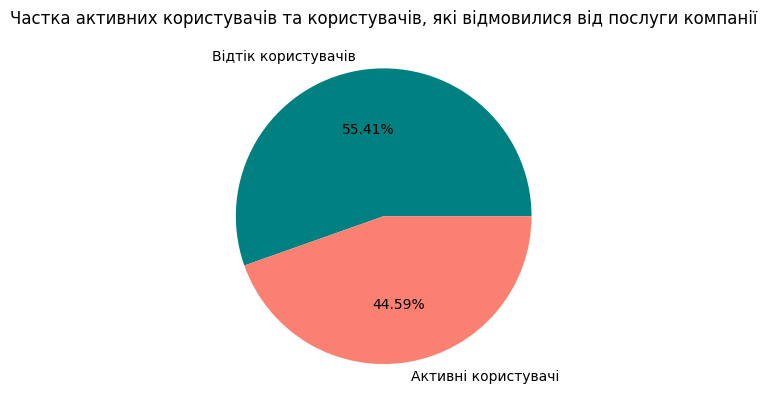

In [31]:
data_users = [churned_users,active_users]
labels_users = ['Відтік користувачів','Активні користувачі']
plt.title('Частка активних користувачів та користувачів, які відмовилися від послуги компанії')
plt.pie(data_users,labels=labels_users,autopct="%.2f%%",colors=['Teal','Salmon'],shadow=False, labeldistance=1.1, startangle=0, radius=1)
plt.show()

**Українська версія:**  
Кругова діаграма демонструє, що набір даних містить більше користувачів, які припинили користуватися послугами, і їхня частка становить 55,41%.
**English version:**     
The piechart illustrates that the dataset contains more churned users and their proportion contains 55.41%. 

### 2. Огляд відтоку клієнтів за типами підписки (Overview of Customer Churn by Subscription Type)

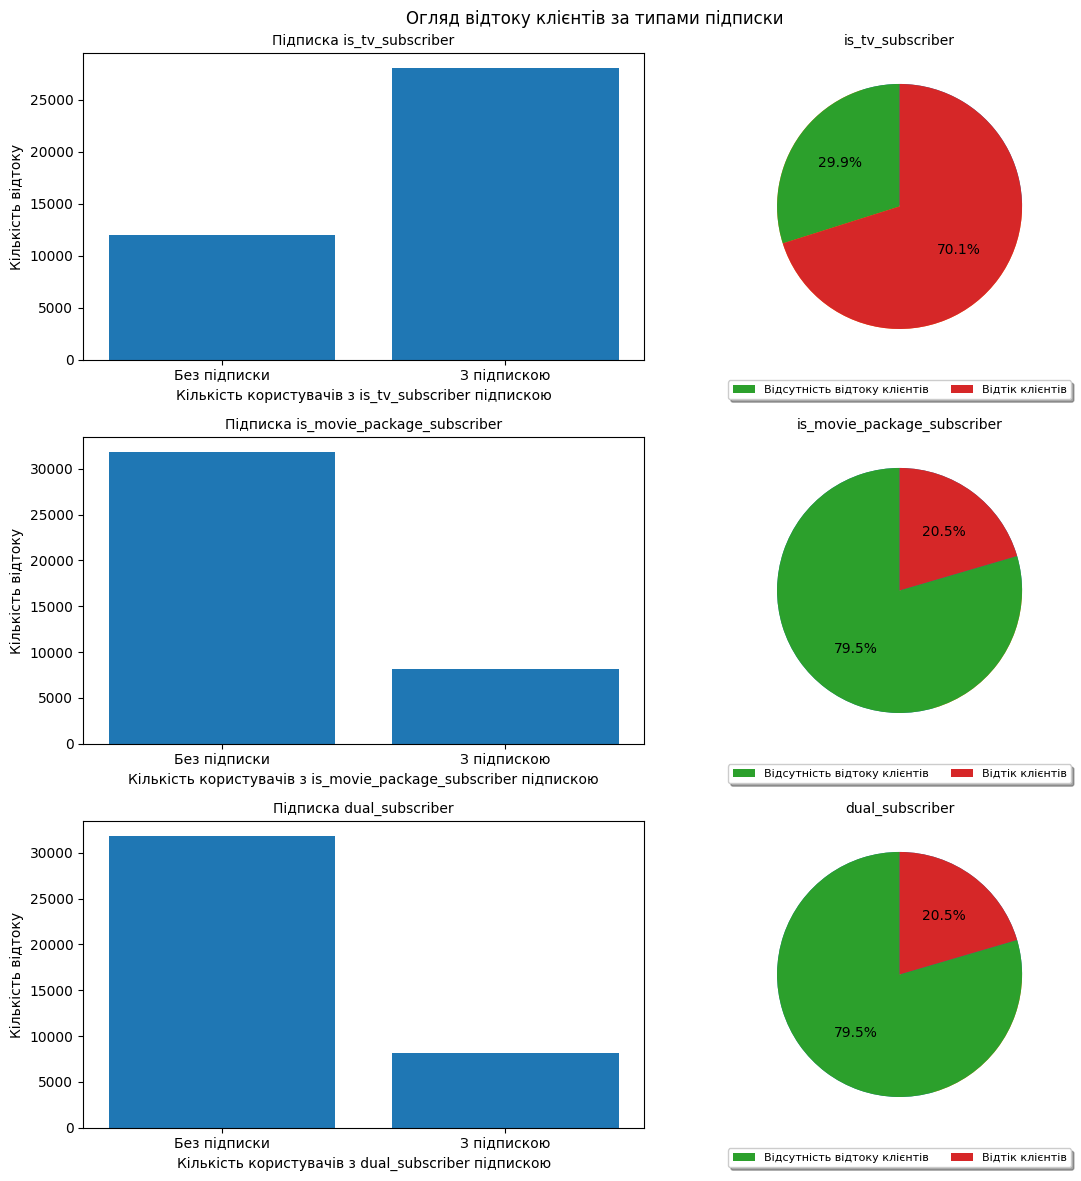

In [32]:
rows = ['is_tv_subscriber', 'is_movie_package_subscriber', 'dual_subscriber']

x = ['Без підписки', 'З підпискою']
churn_status = ['Відсутність відтоку клієнтів', 'Відтік клієнтів']
graphichs_amount = 6
fig, axs = plt.subplots(len(rows), 2, figsize=(12,12))
for i, col in enumerate(rows):
        churn_count = df_copy.groupby(rows[i])['churn'].sum().sort_index(ascending=True)
        axs[i,0].bar(x,churn_count,label=rows[i])
        axs[i,0].set_title(f'Підписка {rows[i]}',fontsize=10)
        axs[i,0].set_xlabel(f'Кількість користувачів з {rows[i]} підпискою')
        # axs[i,0].set_xlabel(f'Users quantity with a {rows[i]} subscription') 
        axs[i,0].set_ylabel('Кількість відтоку')
        
        axs[i,1].pie(churn_count)
        axs[i,1].set_title(rows[i],fontsize=10)
        wedges, texts, autotexts = axs[i,1].pie(
            churn_count,
            autopct='%1.1f%%',  
            startangle=90
        )
        axs[i,1].legend(
            wedges, churn_status,           
            loc='upper center',
            bbox_to_anchor=(0.5, -0.05), 
            shadow=True,
            ncol=2,
            fontsize=8
        )

fig.suptitle('Огляд відтоку клієнтів за типами підписки')
plt.tight_layout()
# fig.suptitle('Overview of Customer Churn by Subscription Type ')
plt.show()

In [33]:
df_copy['is_movie_package_subscriber'].sum(), df_copy['dual_subscriber'].sum()

(24185, 24183)

**Українська версія:**  
На основі отриманих графіків можна чітко помітити, що понад 70 % користувачів із підпискою на телебачення відмовилися від телекомунікаційних послуг, тоді як 79,5 % користувачів, які мають підписку на фільми, не відмовилися від послуг, що доводить: підписка на пакет фільмів є важливою причиною збереження телекомунікаційних послуг. Крім того, абоненти, які мають підписку як на кінопакет, так і на подвійний пакет, демонструють однакові результати за відсотковою різницею, і лише 2 користувачі мають підписку на кінопакет, але не мають підписки на телебачення.

**English version:**     
Based on the graphs provided, it is clear that over 70% of users with a TV subscription canceled their telecommunications services, while 79.5% of users with a movie subscription did not cancel their services, which proves that a movie package subscription is a key factor in retaining telecommunications services. In addition, subscribers who have subscriptions to both the movie package and the dual package show identical results in terms of percentage difference, and only 2 users have a subscription to the movie package but do not have a TV subscription.

### 3. Графік взаємозв’язку між тривалістю підписки та відтоком клієнтів (The graph between subscription duration and customer churn)

In [34]:
### Українська версія: Кількість відтоку за інтервалом тривалості підписки
# English version: Churn volume by subscription age interval

min_subscription_age = df_copy['subscription_age'].min()
max_subscription_age = df_copy['subscription_age'].max()
column_comparison = 'subscription_age'
sub_age_interval = 0.5
sub_procedural_slip = 0.2

necessary_dict = get_churn_distribution(min_subscription_age, max_subscription_age,column_comparison,sub_age_interval,sub_procedural_slip)
list_subscription_ages,list_churn_quantity = return_results_as_lists(min_subscription_age, max_subscription_age,column_comparison, necessary_dict,sub_age_interval,sub_procedural_slip)

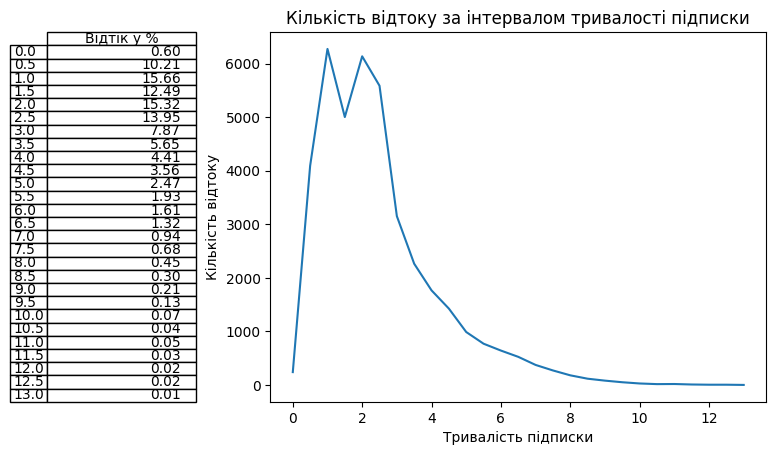

In [35]:
total_churn = sum(list_churn_quantity)
cell_text = [['%1.2f' % ((x / total_churn) * 100)] for x in list_churn_quantity]
plt.plot(list_subscription_ages,list_churn_quantity)
plt.title('Кількість відтоку за інтервалом тривалості підписки')
plt.xlabel('Тривалість підписки')
plt.ylabel('Кількість відтоку')
# plt.title('Churn volume by subscription age interval')
    
the_table = plt.table(cellText=cell_text,rowLabels=list_subscription_ages,colLabels=['Відтік y %'], loc='left',bbox=[-0.45, 0, 0.3, 1] )
the_table.auto_set_font_size(False)
the_table.set_fontsize(10)
plt.show()

**Українська версія:**      
На основі графіка видно, що найбільший рівень відтоку спостерігається в період від 0,5 до 2,5 років, після чого, починаючи з 3,0 років, відбувається його значне зниження. Отже, це свідчить про те, що позначка 3,0 роки є межею, після якої показники відтоку суттєво зменшуються.

**English version:**   
The graph shows that the highest rate of churns occurs between 0.5 and 2.5 years, followed by a significant decline starting at the 3.0-year mark. This indicates that the 3.5-year point serves as a threshold beyond which churns rates decrease substantially.

 ### 4. Графік взаємозв’язку між середнью сумою та відтоком клієнтів (The graph between the average bill amount and customer churn)

In [36]:
min_bill_avg = df_copy['bill_avg'].min()
max_bill_avg = df_copy['bill_avg'].max()
column_bill_avg = 'bill_avg'
bill_avg_interval = 10
bill_procedural_slip = 1
necessary_bill_dict = get_churn_distribution(min_bill_avg, max_bill_avg,column_bill_avg,bill_avg_interval,bill_procedural_slip)
bill_avg_list,churn_quantity_list = return_results_as_lists(min_bill_avg, max_bill_avg,column_bill_avg, necessary_bill_dict,bill_avg_interval,bill_procedural_slip)

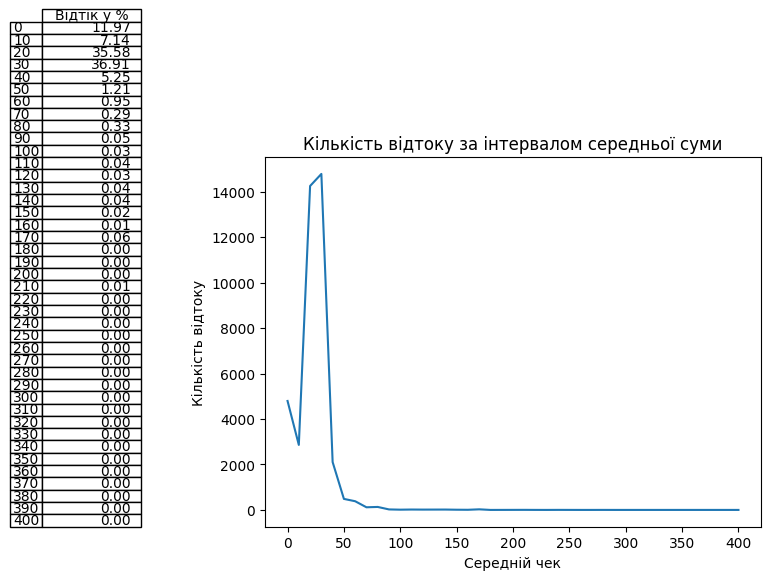

In [37]:
total_churn = sum(churn_quantity_list)
cell_text_bill = [['%1.2f' % ((x / total_churn) * 100)] for x in churn_quantity_list]

plt.plot(bill_avg_list,churn_quantity_list)
plt.title('Кількість відтоку за інтервалом середньої суми')
plt.xlabel('Середній чек')
plt.ylabel('Кількість відтоку')
# plt.title('Churn volume by subscription age interval')
the_table_bill = plt.table(cellText=cell_text_bill,rowLabels=bill_avg_list,colLabels=['Відтік y %'], loc='left',bbox=[-0.45, 0, 0.2, 1.4] )
the_table_bill.auto_set_font_size(False)
the_table_bill.set_fontsize(10)
plt.show()

**Українська версія:**   
Наведений графік показує, що найбільша частка відтоку клієнтів понад 91 % — припадає на середні рахунки, сума яких не перевищує 30. Тому важливо зауважити: чим дорожчий рахунок, тим менша ймовірність того, що користувач відмовиться від підписки.

**English version:**     
The graph below shows that the highest percentage of customer churn over 91% — occurs among medium-sized accounts with balances of 30 or less. Therefore, it is important to note that the more expensive the account, the less likely the user is to cancel their subscription.

### 5.  Графіки взаємозв’язку між тривалістю підписки та середньою сумою рахунку, з розбивкою за рівнем відтоку клієнтів (A graph showing the relationship between the duration of a subscription and the average bill amount, broken down by customer churn rate)

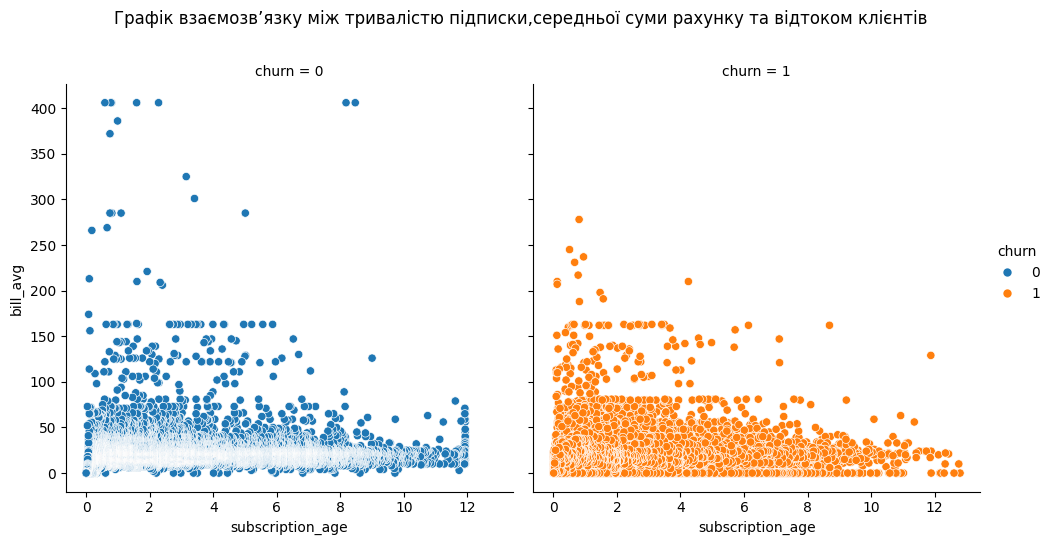

In [38]:
graph = sns.relplot(x='subscription_age',y='bill_avg', hue='churn', col='churn',data=df_copy)
graph.fig.suptitle('Графік взаємозв’язку між тривалістю підписки,середньої суми рахунку та відтоком клієнтів',y=1.08);

**Українська версія:**   
На даному графіку не спостерігається суттєвих відмінностей (через надмірне накладання графіків) у взаємодії змінних bill_avg та subscription_age: показники відтоку клієнтів майже однакові, за винятком того, що користувачі з найдорожчими рахунками не відмовляються від послуг і продовжують користуватися телекомунікаційними послугами.

 **English version:**      
This graph shows no significant differences (because of overplotting) in the interaction between the variables `bill_avg` and `subscription_age`: customer churn rates are nearly identical, except that users with the highest bills do not cancel their services and continue to use telecommunications services.

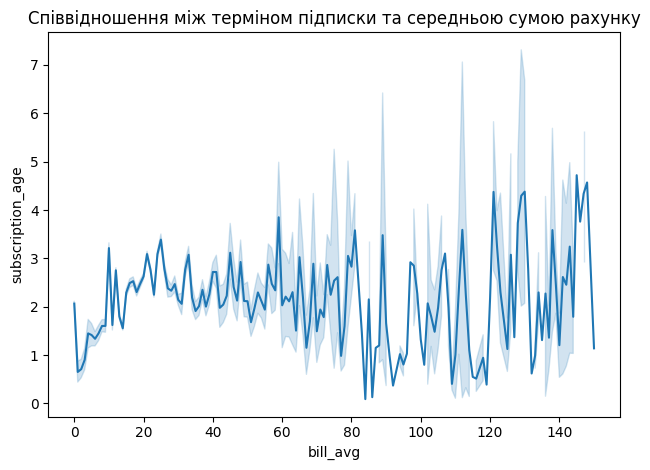

In [39]:
df_filtered = df_copy[df_copy['bill_avg'] <= 150]
sns.lineplot(x='bill_avg',y='subscription_age',data=df_filtered)
plt.title('Співвідношення між терміном підписки та середньою сумою рахунку')
plt.tight_layout()
plt.show()

In [40]:
df_copy['bill_avg'].mean(), df_copy['subscription_age'].mean()

(18.94248277388826, 2.4500514707917094)

**Українська версія:**   
Графік показує середнє значення subscription_age для кожного значення bill_avg (обмежено діапазоном 0–150). Затінена область навколо лінії — це 95% довірчий інтервал, обчислений методом бутстрепінгу. У діапазоні bill_avg від 0 до ~150, де зосереджена переважна більшість клієнтів, середня тривалість підписки коливається приблизно між 1.5 та 5.5 роками, без чіткого монотонного зв'язку між сумою рахунку та тривалістю підписки — тобто клієнти з різними тарифами затримуються в компанії приблизно однаково довго. Після позначки bill_avg ≈ 150 лінія стає різкою та нестабільною, а довірчий інтервал — значно ширшим. Це не відображає реальну закономірність, а є артефактом малої вибірки: лише 93 з 72,274 клієнтів (0.13%) мають bill_avg вище 150, тому середнє значення стає надзвичайно чутливим до окремих викидів.

 **English version:**      
This chart shows the mean subscription_age for each bill_avg value, limited to the range 0–150. The shaded band around the line is a 95% confidence interval, computed through bootstrapping. The range was capped at bill_avg ≤ 150 since this covers 99.87% of all customers (72,181 out of 72,274); values above 150 represent only 93 customers and produced sharp, unreliable fluctuations due to the small sample size. Within this range, average subscription age fluctuates between roughly 1.5 and 5.5 years, with no clear monotonic relationship between bill amount and tenure — customers across different billing levels stay with the company for a similar length of time, regardless of how much they're billed.

### 6. Графіки залежності відтоку клієнтів від кількості збоїв у наданні послуг (Graph showing the relationship between customer churn and the number of service outages)

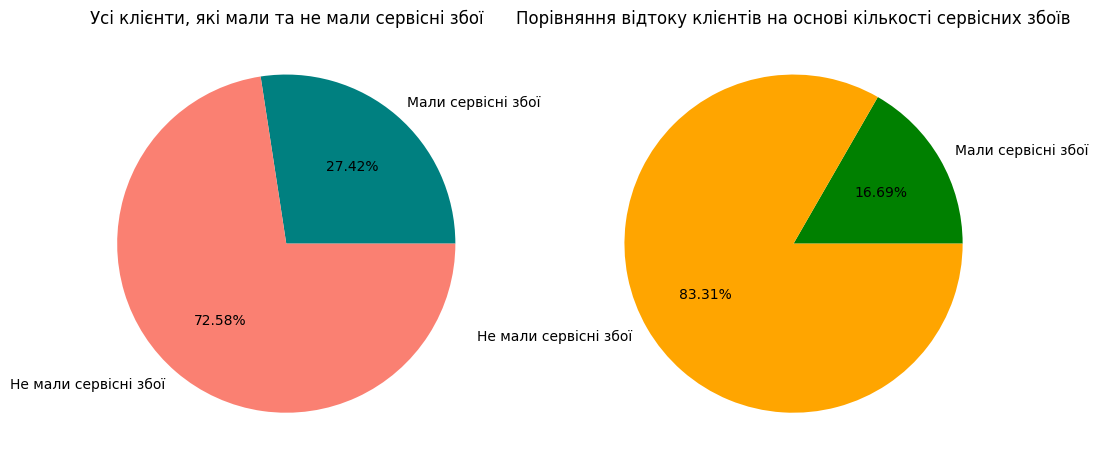

In [41]:
column_service_failure = 'service_failure_count'

labels_all = ['Мали сервісні збої','Не мали сервісні збої']

title_service_all = 'Усі клієнти, які мали та не мали сервісні збої'
title_service_churns = 'Порівняння відтоку клієнтів на основі кількості сервісних збоїв'
result = show_all_churn_piecharts(column_service_failure,labels_all,title_service_all,title_service_churns)
result   

**Українська версія:**     
Кругова діаграма показує, що, хоча 27,42 % усіх клієнтів стикалися з перебоями в наданні послуг, серед клієнтів, які відмовилися від послуг, таких було менше (а саме 16,69 %), що означає, що наявність перебоїв у наданні послуг не є вирішальним фактором для припинення користування телекомунікаційними послугами.

**English version:**      
The pie chart shows that, although 27.42% of all customers experienced service failures, the percentage was lower among customers who canceled their services (namely, 16.69%), which means that service interruptions are not a decisive factor in discontinuing the use of telecommunications services.

In [42]:
min_service_failure = float(df_copy['service_failure_count'].min())
max_service_failure = float(df_copy['service_failure_count'].max())
column_service_failure = 'service_failure_count'
service_failure_interval = 1
service_failure_procedural_slip = 1

necessary_service_dict = get_churn_distribution(min_service_failure, max_service_failure,column_service_failure,service_failure_interval,service_failure_procedural_slip)
service_failure_list,churn_quantity_list_f = return_results_as_lists(min_service_failure, max_service_failure,column_service_failure, necessary_service_dict,service_failure_interval,service_failure_procedural_slip)

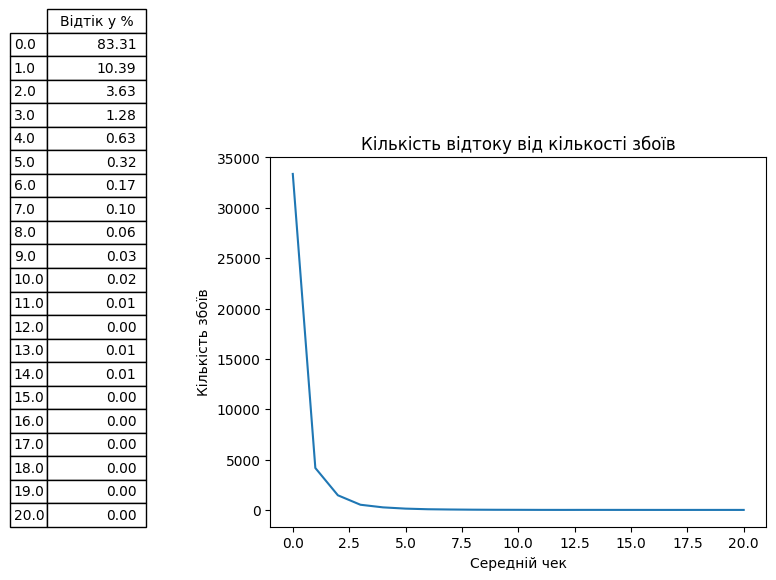

In [43]:
total_churn = sum(churn_quantity_list_f)
cell_text_service_failure = [['%1.2f' % ((x / total_churn) * 100)] for x in churn_quantity_list_f]

plt.plot(service_failure_list,churn_quantity_list_f)
plt.title('Кількість відтоку від кількості збоїв')
plt.xlabel('Середній чек')
plt.ylabel('Кількість збоїв')
# plt.title('Churn volume by subscription age interval')
the_table_service_failure = plt.table(cellText=cell_text_service_failure,rowLabels=service_failure_list,colLabels=['Відтік y %'], loc='left',bbox=[-0.45, 0, 0.2, 1.4] )
the_table_service_failure.auto_set_font_size(False)
the_table_service_failure.set_fontsize(10)
plt.show()

**Українська версія:**     
Графік демонструє, що 10,39% випадків відтоку клієнтів спричинені першим збоєм у наданні послуги, а другий збій призводить до 3,63% відтоку, тоді як подальші збої не мають суттєвого впливу на цей показник.

**English version:**      
The graph shows that 10.39% of customer churn cases are caused by the first service failure, and a second failure leads to 3.63% churn, whereas subsequent failures do not have a significant impact on this figure.

In [44]:
df_copy.columns

Index(['id', 'is_tv_subscriber', 'is_movie_package_subscriber',
       'subscription_age', 'bill_avg', 'remaining_contract',
       'service_failure_count', 'download_avg', 'upload_avg',
       'download_over_limit', 'churn', 'dual_subscriber', 'has_contract_info',
       'has_active_contract'],
      dtype='object')

### 7. Графіки відтоку клієнтів, які мають чинні контракти (The graph of customer churn for active contracts)

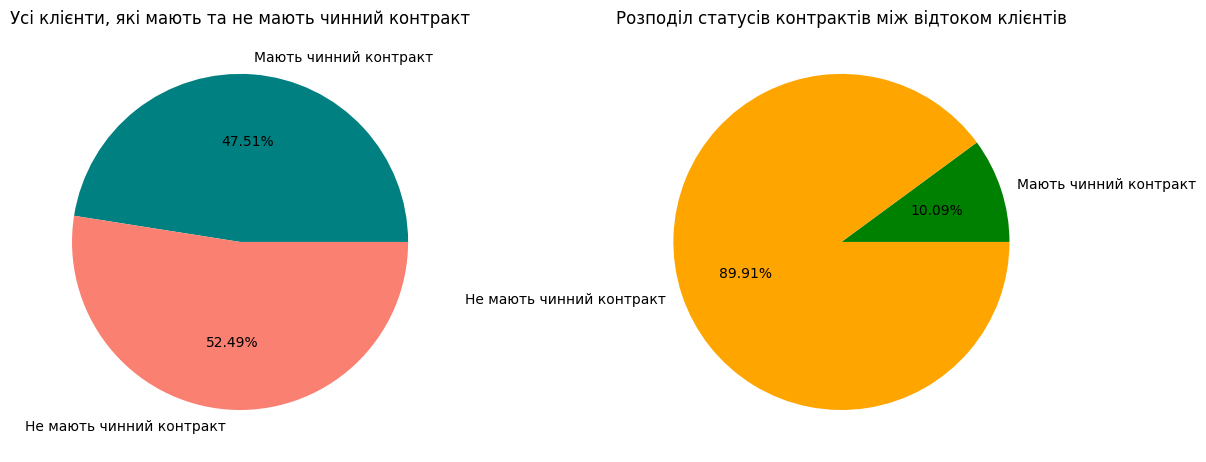

In [49]:
column_has_active_contract = 'has_active_contract'

labels_active_contract = ['Мають чинний контракт','Не мають чинний контракт']

title_has_active_contract = 'Усі клієнти, які мають та не мають чинний контракт'
title_has_active_contract_churns = 'Розподіл статусів контрактів між відтоком клієнтів'
result_active_contracts = show_all_churn_piecharts(column_has_active_contract,labels_active_contract,title_has_active_contract,title_has_active_contract_churns)
result_active_contracts

**Українська версія:**     
Графік демонструє, що 10,39% випадків відтоку клієнтів спричинені першим збоєм у наданні послуги, а другий збій призводить до 3,63% відтоку, тоді як подальші збої не мають суттєвого впливу на цей показник.

**English version:**      
The first pie chart demonstrates that from all customers over 52.49%  do not have an active contract while the churn pie chart shows that 10.09% decided to terminate using company services even with valid contract, that proves a negative tendency that telecommunication services  do not work well in order to keep users, so they dedided to terminate in advance

### ---. Графік кореляції між ознаками (The correlation graph between features)

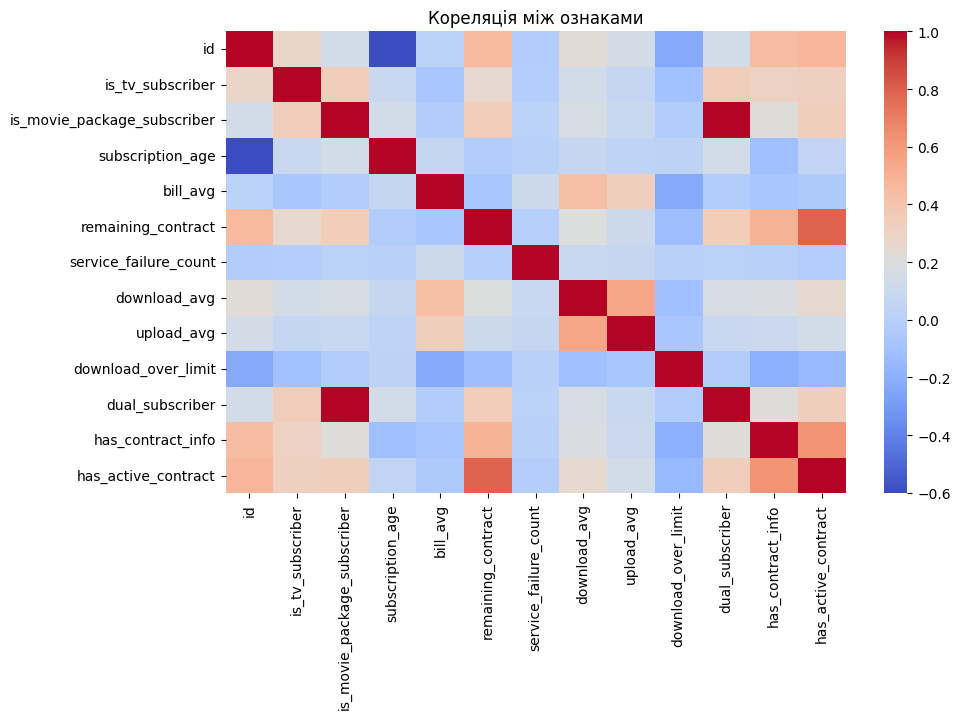

In [46]:
corr_matrix = df_copy.drop(columns='churn').corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False, fmt=".2f")
# plt.title("Correlation between features")
plt.title('Кореляція між ознаками')
plt.show()